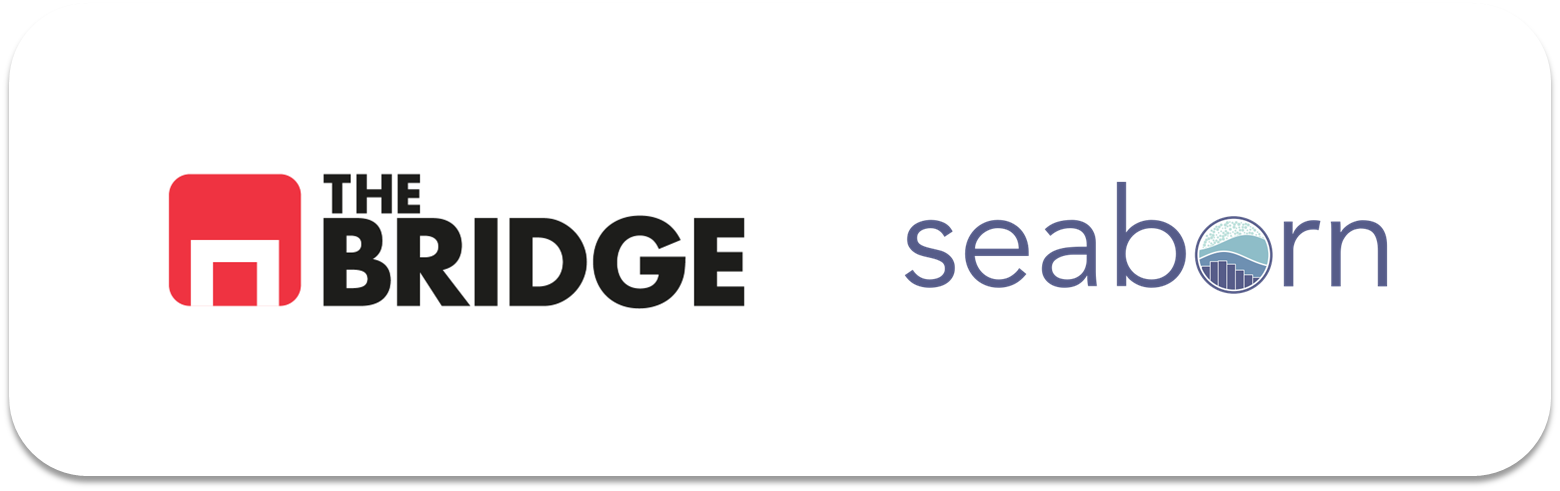

# Visualización Aplicada: Comparando Variables Categóricas

Nos enfocamos ahora ya en visualizar la relación entre dos variables, en concreto entre dos variables categóricas. Lancemos los preparativos:

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

df_titanic = pd.read_csv("./data/titanic.csv")
df_vuelos = pd.read_csv("./data/dataset_viajes_jun23.csv")
df_seguros = pd.read_csv("./data/Marketing-Customer-Analysis.csv")


## Comparando dos variables Categóricas

### Gráficos y consideraciones

Vamos a ver:
* Comparativa de frecuencias por valores de una de las variables (con diagramas de barras y catplot)
* Tablas de contigencia (como mapas de calor)

* **Cuándo**: En análisis bivariantes los dos tipos son convenientes. En presentaciones las tablas de contigencia suelen ser demasiado "informativas" (Como todos los heatmaps si llevan números), pero son visualmente "atractivas" si se usan bien los colores. De usar tablas/mapas de calor quitar los numeros, remarcar la zona donde esté el dato importante que justifique nuestro mensaje.

* **Cuándo no**: En presentaciones, no usar tablas (casi) NUNCA (sí eso nunca, demasiados números y estás out), bueno savo que alguien te haya pedido que quiere ver los números de esa tabla o la tabla sea de dos por dos. Los mapas de calor sin números salvo en las casillas realmente relevantes.

* **Genérico**: Además si las variables tienen cardinalidades altas, en presentación aplica lo que ya dijimos crear categorías otros para poner allí las categorias no relevantes de una y otra variable (si es necesario no mostrarla)

### Catplot comparativa de frecuencias con Seaborn

Antes de empezar con las gráficas no está de más recordar como obtener las frecuencias de una variable (las de dos lo veremos en las tablas de contingencia):


In [2]:
# Obtener las freceuncias absolutas y relativas de la variable/columna "state" del dataset df_seguros

frecuencias_absolutas = df_titanic["who"].value_counts()
frecuencias_relativas = df_titanic["who"].value_counts(normalize = True) *  100

print(frecuencias_absolutas)
print(frecuencias_relativas)

who
man      537
woman    271
child     83
Name: count, dtype: int64
who
man      60.269360
woman    30.415264
child     9.315376
Name: proportion, dtype: float64


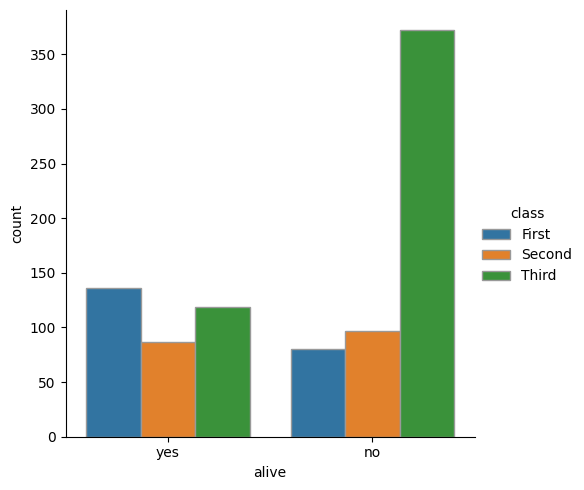

In [ ]:
#### Tablas de frecuencias absolutas modo 1
sns.catplot(x="alive",
            hue="class", # el diagrama de color nos lo define "class"
            kind="count", # Me permite diferentes tipos de gráficos sobre variables 
            edgecolor= ".6",
            orient = "V",
            data = df_titanic.sort_values("class"));

# alive, yes no y un codigo de color para los diferentes tipos de clases,
# sobrevivieron




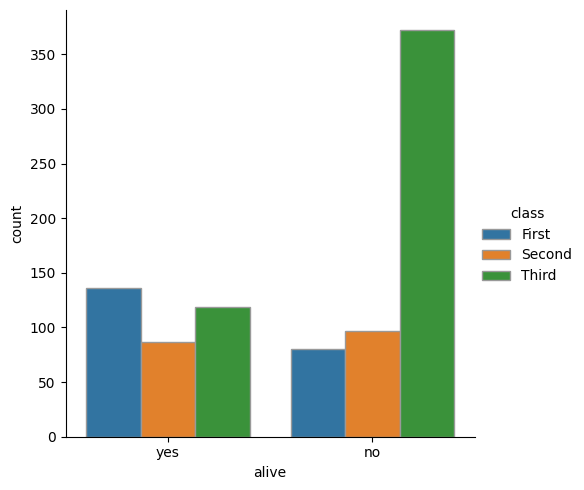

In [9]:
#### Tablas de frecuencias absolutas modo 1

sns.catplot(
    x="alive",                 # Variable categórica principal (Yes / No)
    hue="class",               # Colores según la clase del pasajero (First, Second, Third)
    kind="count",              # Tipo de gráfico: conteo de frecuencias absolutas
    edgecolor=".6",            # Borde suave para las barras
    orient="V",                # Orientación vertical
    data=df_titanic.sort_values("class")   # Ordena por clase para consistencia visual
);

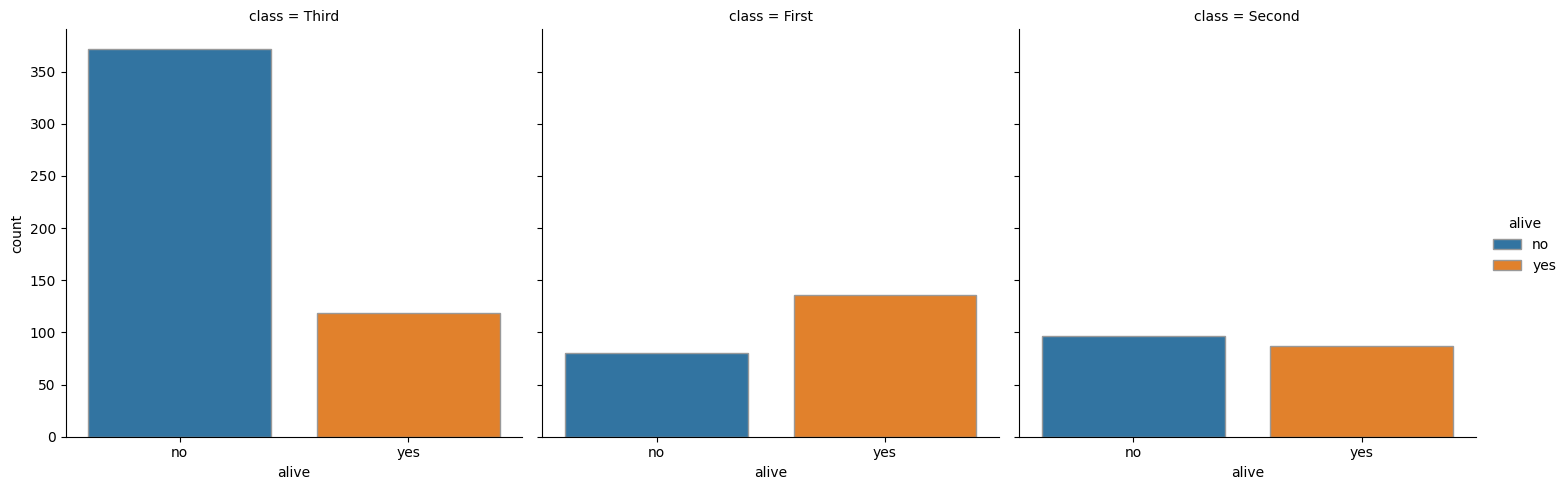

In [4]:
# Tabla de frecuencias modo 2
sns.catplot(x="alive",
            col = "class",
            kind="count",
            edgecolor=".6",
            orient = "V",
            hue = "alive",
            legend= True,
            data=df_titanic);

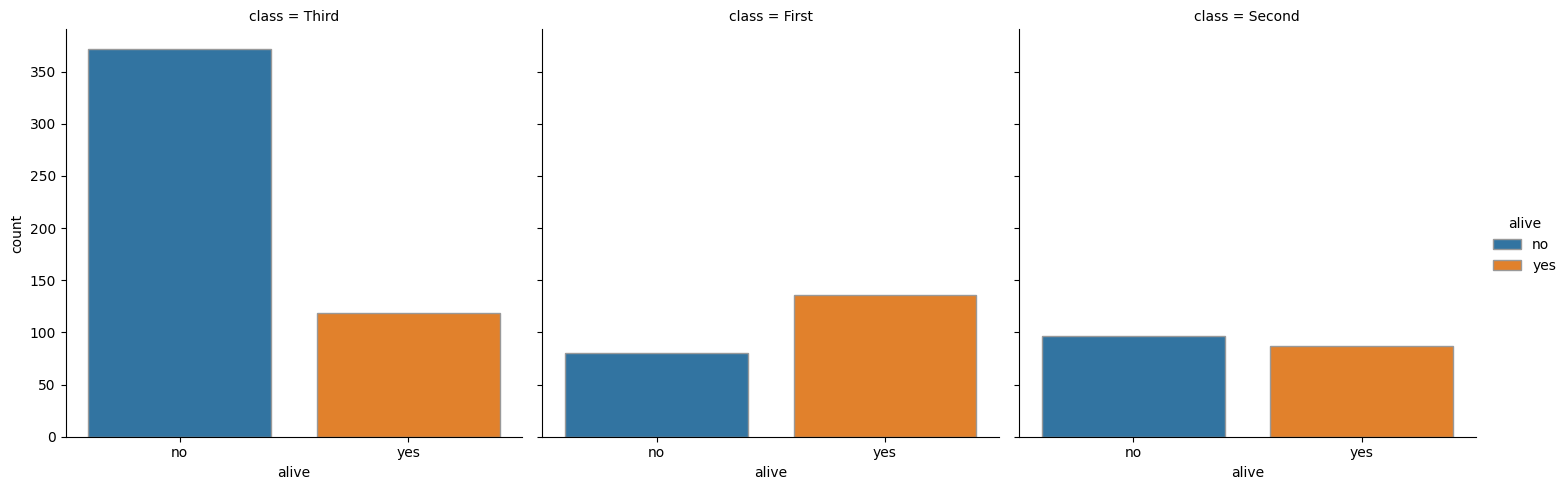

In [11]:
# Tabla de frecuencias modo 2

sns.catplot(
    x="alive",              # Variable principal (Yes / No)
    col="class",            # Crea una columna de gráficos por cada clase (First, Second, Third)
    kind="count",           # Tipo de gráfico: conteo de frecuencias absolutas
    edgecolor=".6",         # Borde suave para las barras
    orient="V",             # Orientación vertical
    hue="alive",            # Colorea según alive (Yes / No)
    legend=True,            # Muestra la leyenda
    data=df_titanic         # DataFrame de origen
);

Si queremos frecuencias relativas, primero tenemos que calcularlas y luego ya aplicamos una visualización:

In [5]:
#AC
cat_colx = "alive"
cat_coly = "class"
frecuencias_absolutas = df_titanic.groupby(cat_coly, as_index = False)[cat_colx].value_counts()
frecuencias_relativas = df_titanic.groupby(cat_coly, as_index = False)[cat_colx].value_counts(normalize=True)
print(frecuencias_absolutas)
print(frecuencias_relativas)

    class alive  count
0   First   yes    136
1   First    no     80
2  Second    no     97
3  Second   yes     87
4   Third    no    372
5   Third   yes    119
    class alive  proportion
0   First   yes    0.629630
1   First    no    0.370370
2  Second    no    0.527174
3  Second   yes    0.472826
4   Third    no    0.757637
5   Third   yes    0.242363


In [6]:
frecuencias_relativas["proportion"] *= 100

In [7]:
frecuencias_relativas

,class,alive,proportion
0,First,yes,62.962963
1,First,no,37.037037
2,Second,no,52.717391
3,Second,yes,47.282609
4,Third,no,75.763747
5,Third,yes,24.236253


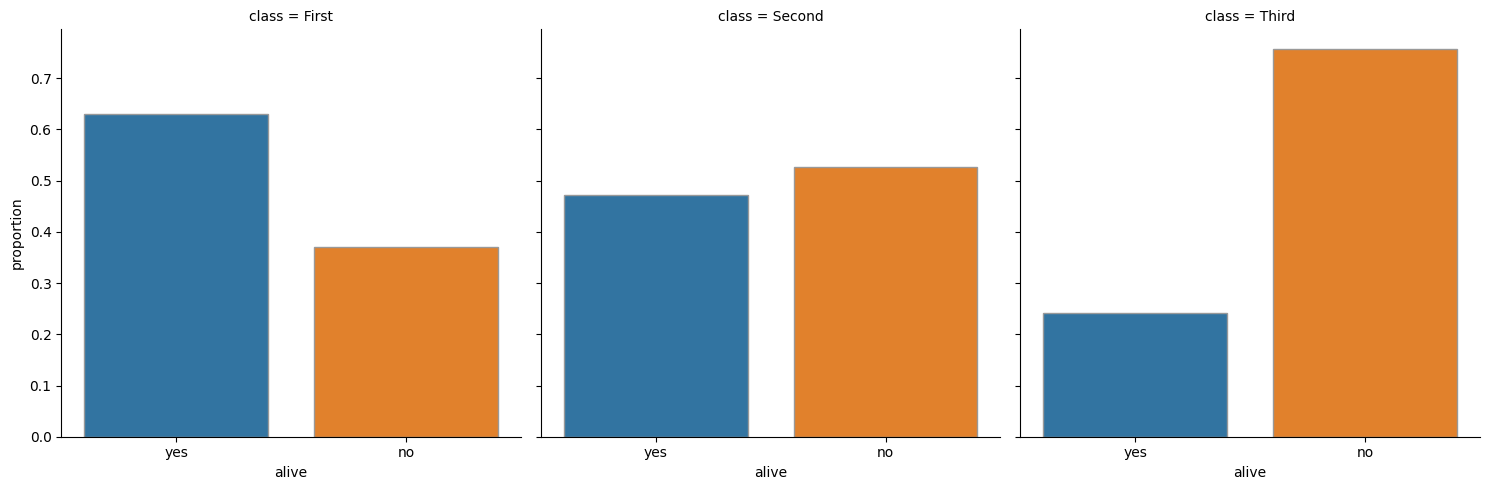

In [6]:
# Pintamos modo1
sns.catplot(x="alive",
            y = "proportion",
            col="class",
            hue = "alive",
            kind="bar", # Ojo, cambio el tipo de gráfico (ahora no "cuento" filas)
            edgecolor=".6",
            data=frecuencias_relativas);

In [7]:
df_titanic.groupby(cat_coly, as_index = False)[cat_colx].value_counts(normalize = True).values

array([['First', 'yes', 0.6296296296296297],
       ['First', 'no', 0.37037037037037035],
       ['Second', 'no', 0.5271739130434783],
       ['Second', 'yes', 0.47282608695652173],
       ['Third', 'no', 0.7576374745417516],
       ['Third', 'yes', 0.24236252545824846]], dtype=object)

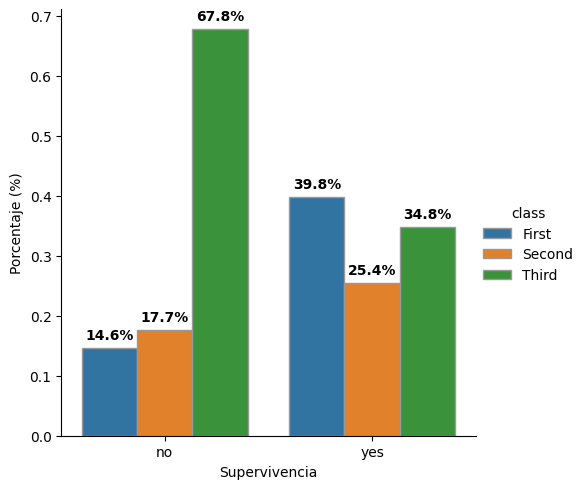

In [15]:
# 1. Tabla de frecuencias relativas SIN errores de índice
tabla_rel = (
    df_titanic
    .groupby(["alive", "class"])
    .size()
    .reset_index(name="conteo")        # ← evita el conflicto de columnas
)

# 2. Convertimos a porcentajes dentro de cada categoría de alive
tabla_rel["porcentaje"] = (
    tabla_rel.groupby("alive")["conteo"].transform(lambda x: x / x.sum())
)

# 3. Gráfico
g = sns.catplot(
    data=tabla_rel,
    x="alive",
    y="porcentaje",
    hue="class",
    kind="bar",
    edgecolor=".6"
)

# 4. Cambiar labels
g.set_axis_labels("Supervivencia", "Porcentaje (%)")

# 5. Añadir porcentajes encima de cada barra
ax = g.axes[0][0]

for p in ax.patches:
    altura = p.get_height()

    if altura == 0:
        continue

    ax.text(
        p.get_x() + p.get_width()/2,
        altura + 0.01,
        f"{altura*100:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )



### Tablas de contingencia y Mapas de Calor

Otra forma numérica de ver las frecuencias de aparición conjunta de los valores de dos variables categóricas es recurrir a las tablas de contingencia:

In [ ]:
# TABLA DE CONTINGENCIA
tabla_contingencia = pd.crosstab(df_titanic["embark_town"],
                                 df_titanic["who"],
                                 margins = False)
tabla_contingencia


who,child,man,woman
embark_town,,,
Cherbourg,18,90,60
Queenstown,5,37,35
Southampton,60,410,174


Compárala con nuestra forma de obtener frecuencias absolutas:

In [18]:
cat_colx = "who"
cat_coly = "embark_town"
frecuencias_absolutas = df_titanic.groupby(cat_coly, as_index = False)[cat_colx].value_counts()
frecuencias_absolutas

,embark_town,who,count
0,Cherbourg,man,90
1,Cherbourg,woman,60
2,Cherbourg,child,18
3,Queenstown,man,37
4,Queenstown,woman,35
5,Queenstown,child,5
6,Southampton,man,410
7,Southampton,woman,174
8,Southampton,child,60


La primera puede que te resulte más útil a ti visualmente para analizar, la seguda es más manejable en términos de programación.

#### Mapa de calor de la tabla de contigencia:

Si queremos que la tabla de contingencia sea más "presentable", la convertimos en un mapa de calor:

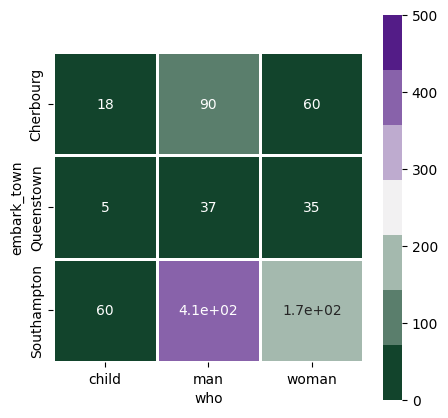

In [19]:
# Mapa de calor de la tabla de contingencias
plt.figure(figsize=(5,5))
sns.heatmap(tabla_contingencia,
            vmin = 0, # valores para determinar el minimo y el maximo de la tabla de valores
            vmax = 500, #
            cmap = sns.diverging_palette(145, 280, s=85, l=25, n=7), # Mapa de color llamativo
            square= True, # dimensiones cuadradas
            linewidths = 1, # anchos de los cuadraditos internos
            annot = True); # nos añada los numeros

# el que llama mas la atención es el valor de hombres que embarcaron en southampton


Bastante visual,¿eh? Incluso más que las barras de frecuencia, si es lo que quiero mostrar... Pero es engorrosa... De usarla cómo lo haría yo:

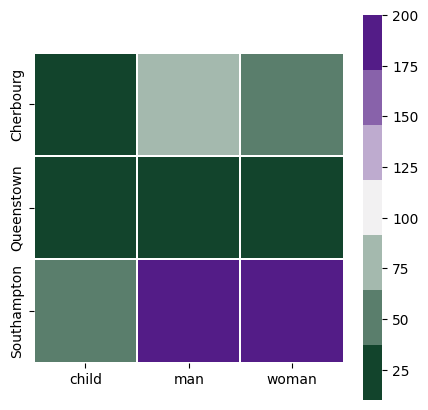

In [20]:

plt.figure(figsize=(5,5))
sns.heatmap(tabla_contingencia,
            vmin = 10,
            vmax = 200, # bajamos el valor maximo del rango de valores de los colores 
            cmap=sns.diverging_palette(145, 280, s=85, l=25, n=7),
            square = True,
            linewidths=.1,
            annot=False); # quitar los números
plt.xlabel("") # quitar los label
plt.ylabel("");

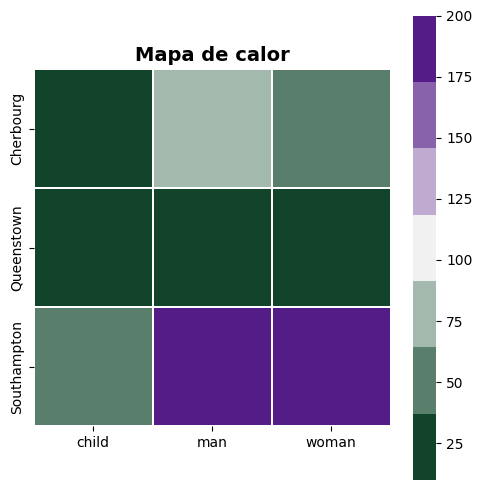

In [24]:
### MAPA DE CALOR: TABLA DE CONTINGENCIA ENTRE EMBARK_TOWN Y WHO

# 1. Crear tabla de contingencia
tabla_contingencia = pd.crosstab(
    df_titanic["embark_town"],   # Filas: puerto de embarque
    df_titanic["who"],           # Columnas: tipo de pasajero (man / woman / child)
    margins=False                # No añadir totales
)

# 2. Crear figura
plt.figure(figsize=(5,5))        # Tamaño del gráfico

# 3. Mapa de calor
sns.heatmap(
    tabla_contingencia,          # Matriz de contingencia
    vmin=10,                     # Valor mínimo del rango de colores
    vmax=200,                    # Valor máximo (bajado para más contraste)
    cmap=sns.diverging_palette(145, 280, s=85, l=25, n=7),  # Paleta personalizada
    square=True,                 # Celdas cuadradas
    linewidths=.1,               # Líneas finas entre celdas
    annot=False                  # No mostrar números dentro de las celdas
)

# 4. Título del mapa de calor
plt.title("Mapa de calor",
          fontsize=14, weight="bold")

# 5. Quitar labels de ejes para diseño más limpio
plt.xlabel("")
plt.ylabel("")

# 6. Mostrar gráfico
plt.tight_layout()
plt.show()
